In [1]:
%%html
<style>
    h1 {color:purple}
    h2 {color:purple}
    h3 {color:#0099ff}
    hr {    
        border: 0;
        height: 3px;
        background: #333;
        background-image: linear-gradient(to right, limegreen, deepskyblue, limegreen);
    }
</style>

# Creating Agents with the OpenAI Agents SDK
---
# Voice-Enabled Deitel Book Concierge with GPT-Live
* Adds a real-time voice front end to the multi-agent book concierge from `02-05-03`
    * Same triage agent, handoffs, `FileSearchTool` and `WebSearchTool`
    * See `02-05-03` for RAG, vector stores and handoffs
* **GPT-Live** (`gpt-live-1`) — OpenAI's full-duplex voice model
    * Listens and speaks at the same time
    * Handles interruptions and decides when turns start and stop
    * **Delegates** reasoning and tool use to a backend agent
* Costs $0.05 per voice minute, billed per second, plus backend model and tool usage
    * Not available on the Free usage tier
---

## GPT-Live Splits Conversation from Work
* **GPT-Live handles the conversation** — listening, speaking, backchannels ("mm-hmm") and interruptions
* **A backend handles delegated work** — reasoning, tool calls and business rules
* Sending work to the backend is called **delegation**
    * The conversation can continue while the work runs
* Compare with the **Realtime API** (`gpt-realtime-2.1`)
    * One model handles speech, reasoning *and* tool selection
    * The Agents SDK's `RealtimeAgent` and `RealtimeRunner` use the Realtime API
    * `gpt-live-1` uses a different endpoint (`v1/live/sessions`), so this example uses the OpenAI Python SDK's `client.live` for voice
---

## Two Delegation Modes

| | Responses delegation | Client delegation |
|---|---|---|
| **Who runs the backend** | GPT-Live calls a Responses model you configure | Your application runs any model, agent or service |
| **Backend tools** | `function` definitions and `web_search` only | Anything your code can do |
| **Who builds the context** | GPT-Live | Your application, from transcripts |
| **Who returns results** | GPT-Live | Your application |

* **This example requires client delegation**
    * The concierge depends on `FileSearchTool`, which Responses delegation does not support
    * Client delegation lets us reuse the multi-agent concierge — handoffs included
* OpenAI's GPT-Live migration guide describes this pattern for adding voice to an existing text agent
---

## How One Spoken Question Flows
1. Microphone audio streams continuously to GPT-Live (`session.input_audio.append`)
2. GPT-Live transcribes both speakers (`session.input_transcript.delta`, `session.output_transcript.delta`)
    * Our application keeps these fragments — the delegation event carries **no request text**
3. GPT-Live decides it needs the backend and sends `session.delegation.created`
    * It contains only an opaque delegation ID
4. Our application builds a request from the recent transcript and runs the triage agent
5. While the agent works, our application sends **quiet progress** (`session.thinking.append`)
6. When the agent finishes, our application sends the **verified result** (`session.commentary.append`)
7. GPT-Live paraphrases the result aloud — and can keep talking with the user the whole time
---

## Idiomatic GPT-Live Practices in This Example
Based on OpenAI's GPT-Live prompting, delegation and session guides:
* **Two prompts with separate jobs**
    * A short *conversation* prompt for GPT-Live — personality, backchannels, interruptions and **when to delegate**
    * Detailed task rules stay in the *backend* agents' instructions
* **Backend prompts adapted for voice**
    * Transcripts can contain mistakes, unfinished phrases and corrections
    * Return plain spoken facts — no Markdown or URLs for GPT-Live to read aloud
* **The right update for each purpose**
    * `session.thinking.append` — quiet progress when the triage agent hands off to a specialist
    * `session.commentary.append` — the verified answer, at most 500 tokens
* **Task state owned by the application**
    * Duplicate delegations are ignored
    * A newer request, such as a correction, cancels the older lookup
    * Outdated results are discarded rather than spoken
* **Prepared backend** — agents are created once, before the session starts
* **Graceful close** — waits for `session.closed` to report final usage
---

## Before You Run It
* `openai` 3.13 or later with the `realtime` extra, and `sounddevice` — the course setup installs both
* **Use headphones**
    * GPT-Live is full duplex — through laptop speakers it hears itself and interrupts its own answers
    * For a room-speaker demo, pass `echo_guard=True`
        * Sends silence while the concierge speaks, but gives up interrupting it
* The two vector stores from `02-05-03` must exist in your OpenAI project
---

## Vector Store IDs

In [2]:
JHTP_VS_ID = 'vs_6a260a96a6148191bba23f657fcf90ea'  # Java How to Program 12/e
PYTHON_VS_ID = 'vs_6a260ba3bcdc8191952f212e5555665a'  # Intro to Python

In [3]:
from openai import OpenAI
client = OpenAI()

for store_id in [JHTP_VS_ID, PYTHON_VS_ID]:
    store = client.vector_stores.retrieve(store_id)
    print(f'{store.name}\nID={store_id}\n{store.status=}\n{store.usage_bytes=:,d}\n') 

jhtp12
ID=vs_6a260a96a6148191bba23f657fcf90ea
store.status='completed'
store.usage_bytes=699,312

IntroToPython1
ID=vs_6a260ba3bcdc8191952f212e5555665a
store.status='completed'
store.usage_bytes=365,511



---
## Create the Backend Agents

### Imports

In [4]:
from agents import Agent, ModelSettings, Runner, handoff, trace
from agents.extensions.handoff_prompt import (
    prompt_with_handoff_instructions
)
from agents.tool import FileSearchTool, WebSearchTool
from openai.types.live.session_config_param import SessionConfigParam
from source.live_voice import DelegationRequest, run_live_voice_agent

---
### Adapting the Backend Instructions for Voice
* Start from the `02-05-03` instructions and keep their task rules
* Add OpenAI's recommended **voice conversation context** and **return the result** sections
* Replace display formatting with spoken facts
    * `02-05-03` required Markdown headings (`**Book:**`, `**Chapter/section:**`) and URLs
    * GPT-Live paraphrases results aloud, so the backend returns plain sentences instead

In [5]:
VOICE_CONTEXT = """
## Voice conversation context
You are helping an assistant in a live voice conversation. The request
arrives as a recent transcript. Transcripts can contain mistakes,
unfinished phrases, and later corrections. Use the latest context. If a
needed detail is still unclear, ask for that detail instead of guessing.
"""

RETURN_RESULT = """
## Return the result
Return plain sentences that will be spoken aloud. Do not use Markdown,
bullet lists, tables, or URLs. Keep the answer under 100 words. Include
only facts supported by your tools. Do not invent chapter or section
numbers.
"""

WEB_SUFFIX = """
You also have access to the WebSearchTool. Use it only to supplement an
in-scope book answer with current official documentation or recent
language or library updates not covered in the book edition. Do not use
web search for unrelated or out-of-scope requests. Name a resource, such
as "the official Python documentation," instead of reading a URL.
"""

In [6]:
JAVA_INSTRUCTIONS = prompt_with_handoff_instructions(VOICE_CONTEXT + """
## Task instructions
You are the Java book concierge for the textbook
Java How to Program, 12/e by Deitel.

Scope:
- Answer only questions about this Java book, its table of contents, its
  index, its preface, Java topic coverage, Java chapter/section location,
  and Java study paths based on this book.
- If the request is unrelated to Java or this book, do not answer it. Say:
  "This concierge is limited to Java How to Program, 12/e. Please ask
  a question about that book or its Java topics."

Use the FileSearchTool first for book questions. Do not claim a topic is
covered unless file search supports it.

Begin a substantive answer by naming the book and the chapter or section
where the topic appears. If file search does not find it, say it was not
found in the book's indexed preface, table of contents, and index.
""" + WEB_SUFFIX + RETURN_RESULT)

In [7]:
PYTHON_INSTRUCTIONS = prompt_with_handoff_instructions(VOICE_CONTEXT + """
## Task instructions
You are the Python book concierge for the textbook Intro to
Python for Computer Science and Data Science by Deitel.

Scope:
- Answer only questions about this Python book, its table of contents, its
  index, its preface, Python/data-science topic coverage, chapter/section
  location, and study paths based on this book.
- If the request is unrelated to Python, data science or this book, do not
  answer it. Say: "This concierge is limited to Intro to Python for
  Computer Science and Data Science. Please ask a question about that book
  or its Python/data-science topics."

Use the FileSearchTool first for book questions. Do not claim a topic is
covered unless file search supports it.

Begin a substantive answer by naming the book and the chapter or section
where the topic appears. If file search does not find it, say it was not
found in the book's indexed preface, table of contents, and index.
""" + WEB_SUFFIX + RETURN_RESULT)

### Creating the Specialist `Agent` Objects
* Same hybrid-RAG specialists as `02-05-03`, with the voice-adapted instructions

In [8]:
java_agent = Agent(
    name='JavaConcierge',
    model='gpt-5.6-terra',
    instructions=JAVA_INSTRUCTIONS,
    tools=[
        FileSearchTool(vector_store_ids=[JHTP_VS_ID], max_num_results=10),
        WebSearchTool()
    ]
)

python_agent = Agent(
    name='PythonConcierge',
    model='gpt-5.6-terra',
    instructions=PYTHON_INSTRUCTIONS,
    tools=[
        FileSearchTool(vector_store_ids=[PYTHON_VS_ID], max_num_results=10),
        WebSearchTool()
    ]
)

GENERAL_SEARCH_INSTRUCTIONS = prompt_with_handoff_instructions(VOICE_CONTEXT + """
## Task instructions
You are a programming-focused web-search specialist for the Deitel book
concierge demo.

Scope:
- Answer only programming, software-development, Java, Python, data-science,
  or official-documentation questions that are not specific to one indexed
  Deitel book.
- If the request is unrelated to programming, software development, Java,
  Python or data science, do not answer it. Say: "This demo is limited to
  Deitel Java/Python book questions and closely related programming topics."

Use WebSearchTool and prefer official documentation when possible. Name
the sources you use instead of reading URLs.
""" + RETURN_RESULT)

general_search_agent = Agent(
    name='GeneralSearchAgent',
    model='gpt-5.6-terra',
    instructions=GENERAL_SEARCH_INSTRUCTIONS,
    tools=[WebSearchTool()]
)

print('Specialist agents ready:', java_agent.name, python_agent.name,
      general_search_agent.name, sep='\n')

Specialist agents ready:
JavaConcierge
PythonConcierge
GeneralSearchAgent


### Creating the Triage Agent
* Same routing rules as `02-05-03`
* Now routes the **latest request in a transcript**, using earlier turns as context
* Uses low reasoning effort — routing is a simple decision, and every second of backend delay is a pause the user hears

In [9]:
TRIAGE_INSTRUCTIONS = prompt_with_handoff_instructions(VOICE_CONTEXT + """
## Task instructions
You are a routing agent for a Deitel programming book concierge demo.
Available specialists:
- JavaConcierge — Java How to Program, 12/e
- PythonConcierge — Intro to Python for Computer Science and Data Science
- GeneralSearchAgent — programming/software web search for closely related
  topics that are not specific to one indexed Deitel book

Handle the user's latest request in the transcript. Use earlier turns as
context, such as which book the user already chose.

Routing rules:
- Route Java book questions, Java topic-coverage questions, Java chapter/
  section questions, and Java study-path questions to JavaConcierge.
- Route Python book questions, Python/data-science topic-coverage questions,
  chapter/section questions, and study-path questions to PythonConcierge.
- If the question could apply to both books and the conversation doesn't
  say which book, ask exactly one clarifying question: "Do you mean the Java
  book or the Python book?" Do not route yet.
- Route closely related programming/software questions that are not specific
  to either book to GeneralSearchAgent.
- If the request is unrelated to programming, software development, Java,
  Python, data science or these Deitel books, do not hand off. Reply briefly:
  "This demo is limited to Deitel Java/Python book questions and closely
  related programming topics."

Do not answer Java or Python book questions yourself. Hand off to the
appropriate specialist.
""" + RETURN_RESULT)

triage_agent = Agent(
    name='BookConciergeRouter',
    model='gpt-5.6-terra',
    model_settings=ModelSettings(reasoning={'effort': 'low'}),
    instructions=TRIAGE_INSTRUCTIONS,
    handoffs=[
        handoff(java_agent),
        handoff(python_agent),
        handoff(general_search_agent)
    ]
)

print('Triage agent ready:', triage_agent.name)

Triage agent ready: BookConciergeRouter


## Visualizing the Backend Agent Workflow

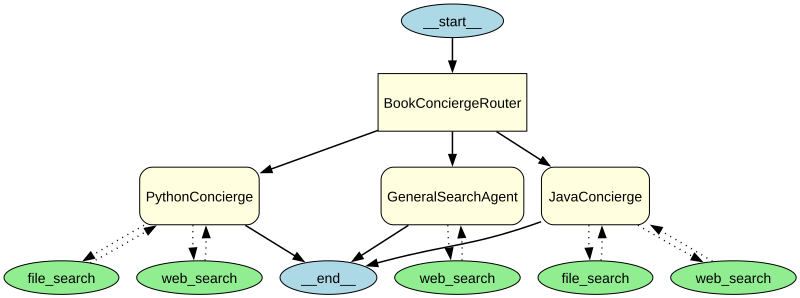

In [10]:
from agents.extensions.visualization import draw_graph
draw_graph(triage_agent)

---
## The Delegation Backend
* `run_live_voice_agent` calls this function once for each client delegation
* It receives a `DelegationRequest`
    * `recent_conversation` — role-labeled transcript built from GPT-Live's transcript fragments
    * `delegation_id` — the opaque ID returned unchanged with every update about this request
    * `live_session_id` — groups every delegation from one voice session in the [traces dashboard](https://platform.openai.com/traces)
* It streams the triage agent's run
    * On a handoff, it reports quiet progress → `session.thinking.append`
* Its return value becomes the spoken result → `session.commentary.append`

In [11]:
PROGRESS_MESSAGES = {
    'JavaConcierge': 'Searching the Java How to Program preface, table of '
                     'contents, and index. No answer yet.',
    'PythonConcierge': 'Searching the Intro to Python preface, table of '
                       'contents, and index. No answer yet.',
    'GeneralSearchAgent': 'Searching the web for current programming '
                          'documentation. No answer yet.',
}

async def concierge_backend(request: DelegationRequest, progress) -> str:
    """Run the book concierge for one GPT-Live delegation."""
    prompt = f"""Recent voice conversation:
{request.recent_conversation}

Handle the user's latest request."""

    with trace('02-05-10-voice-book-concierge',
               group_id=request.live_session_id):
        result = Runner.run_streamed(triage_agent, prompt)

        async for event in result.stream_events():
            # a handoff makes a specialist the current agent
            if (event.type == 'agent_updated_stream_event'
                    and event.new_agent.name in PROGRESS_MESSAGES):
                await progress(PROGRESS_MESSAGES[event.new_agent.name])

    return str(result.final_output)

---
## The GPT-Live Conversation Prompt
* Follows OpenAI's recommended structure for GPT-Live instructions
    * Personality, then **backchannel**, **interruption** and **delegation** policies — keep these labels
* The delegation policy lists **only capabilities the backend actually has**
    * These describe what the backend can help with — they are not tool definitions
* Concrete conditions for when to delegate and when not to
* "Do not guess the result while waiting" keeps GPT-Live from inventing chapter numbers

In [12]:
LIVE_INSTRUCTIONS = """
You are the Deitel Book Concierge, a calm, friendly voice assistant for
questions about two Deitel programming textbooks: Java How to Program,
12/e, and Intro to Python for Computer Science and Data Science.
Speak warmly and naturally, at an unhurried pace. Be clear and direct, not
overly cheerful. Keep answers to one to three sentences.
If the user is frustrated, acknowledge it briefly and focus on the next
helpful step.

Backchannel policy: Use moderate backchannels. Acknowledge naturally
without competing with the main response.

Interruption policy: Stop speaking when the user interrupts. Listen to
what they say.

Delegation policy:
Backend tools:
- Book lookup: find where a topic is covered in either book's preface,
  table of contents, and index, and suggest study paths based on the books.
- Programming web search: find current official documentation and closely
  related programming information that isn't specific to one book.

Delegate to the backend when:
- The user asks where a topic is covered, what a book includes, or for a
  study path.
- The user asks a programming question that needs current or verified
  information.
- A correction changes a lookup already requested, such as switching from
  the Java book to the Python book.

Do not delegate to the backend when:
- The user greets you, thanks you, or asks you to repeat a result already
  provided.
- You need a brief clarification, such as which book the user means.
- The request is unrelated to programming or these books. Briefly say this
  concierge covers Deitel Java and Python book questions and closely
  related programming topics.

Delegate before giving an answer that depends on backend work.
Do not guess chapter or section numbers while waiting.

Keep listening while the user pauses to think.
Do not treat a cough, music, or nearby conversation as a new request.
"""

---
## Session Configuration
* `model` — `gpt-live-1`
* `audio.format` — mono 16-bit PCM at 24 kHz, matching the microphone and speaker streams
* `audio.output.voice` — `marin` is the default
* `delegation` — `{'type': 'client'}`, so our application runs the backend
* The model, instructions, audio settings and delegation mode can't change after the session starts
* The greeting is sent with `session.instructions.append` after the session starts

In [13]:
SESSION_CONFIG: SessionConfigParam = {
    'model': 'gpt-live-1',
    'instructions': LIVE_INSTRUCTIONS,
    'audio': {
        'format': {'type': 'audio/pcm', 'rate': 24_000},
        'output': {'voice': 'marin'},
    },
    'delegation': {'type': 'client'},
}

GREETING = """Greet the user now, in English, in one short sentence as the
Deitel Book Concierge. Say you can find topics in the Java and Python
books. Then pause and listen. Do not wait for the user to speak first."""

---
## Run the Voice Concierge
* Put on headphones, then run the cell
* Speak naturally — you can interrupt the concierge at any time
* Captions show both speakers; bracketed lines show backend activity
    * A backend result appearing on screen doesn't mean it's been spoken yet
* End the session by saying **"goodbye"** or choosing **Kernel > Interrupt Kernel**
    * `max_minutes` also stops the session automatically
    * Every path closes gracefully and prints voice time and estimated voice cost

In [14]:
summary = await run_live_voice_agent(
    SESSION_CONFIG,
    concierge_backend,
    greeting=GREETING,
    max_minutes=10,     # cost safety cap for live demos
    echo_guard=False    # set True only when using room speakers
)

GPT-Live session live_u0_EOmpnp3oMtoumLHw6qor6aY1obvgiWVO started.
Speak naturally. Say "goodbye" to end, or interrupt the kernel.

Concierge: Hi, I'm the Deitel Book Concierge. I can help you find topics in the Java and Python books.
You:  Where can I learn about inheritance
Concierge:  Sure—let me check both books.
    [backend result: Do you mean the Java book or the Python book?]

Concierge:  Do you mean the Java book or the Python book?
You:  Java
Concierge:  Okay.
    [backend: Searching the Java How to Program preface, table of contents, and index. No answer yet.]

    [backend result: Java How to Program, 12/e: Start with Chapter 8, Real-World Modeling with Custom Classes, then study Chapter 9, Real-World Modeling with Inheritance, Polymorphism & Interfaces. Chapter 9 covers class hierarchies, the is-a relationship, polymorphism, interfaces, and an Employee payroll case study. ]

Concierge:  In Java How to Program, 12th edition, start with Chapter 8, then go to Chapter 9 for in

### Sample Spoken Prompts
* "Where can I learn about functional programming?"
    * No book is named, so the concierge should ask which book you mean
* "Where can I learn about Java inheritance?"
* "What about in Python?"
    * The transcript carries the context from the previous question
* Correct yourself during a lookup: "Where's inheritance in the Java book — actually, make that the Python book"
    * The newer delegation cancels the older lookup
* "Suggest a data science study path."
* Interrupt a long answer: "Wait — just the chapter, please."
* Off topic: "What's the weather in Boston?"
    * GPT-Live declines briefly without delegating

---
## Inside `source/live_voice.py`
[Open live_voice.py](./source/live_voice.py)

| Server event | What the helper does |
|---|---|
| `session.started` | Records the session ID, starts the microphone and requests the greeting |
| `session.input_transcript.delta`<br>`session.output_transcript.delta` | Keeps fragments exactly as received and prints captions |
| `session.output_audio.delta` | Decodes the base64 PCM audio and queues it for the speaker |
| `session.delegation.created` | Claims the delegation, waits briefly for the transcript to settle and runs the backend |
| `session.usage.updated` | Tracks cumulative voice seconds for the cost estimate |
| `error` | Reports the error without assuming the session ended |
| `session.closed` | Records the final usage and close reason |

---
## References
* [Getting started with GPT-Live](https://developers.openai.com/api/docs/guides/live)
* [Delegation and tools in GPT-Live](https://developers.openai.com/api/docs/guides/live-delegation)
* [Prompting GPT-Live](https://developers.openai.com/api/docs/guides/live-prompting)
* [Managing GPT-Live sessions](https://developers.openai.com/api/docs/guides/live-conversations)
* [Migrate to GPT-Live](https://developers.openai.com/api/docs/guides/live-migration)
* [GPT-Live over WebSockets](https://developers.openai.com/api/docs/guides/voice-websockets?api=live)
* [GPT-Live 1 model and pricing](https://developers.openai.com/api/docs/models/gpt-live-1)

---

&copy; 2026 by Deitel & Associates, Inc. All Rights Reserved. 